In [8]:
r = [0.012 , -0.008, 0.003]
w = [0.4, 0.35, 0.25]

retorno = r[0]* w[0] + r[1]* w[1] + r[2]* w[2]
print(round(retorno))

0


In [33]:
import numpy as np
import yfinance as yf

# Descarga 1 año de datos
tickers = ["AAPL", "TSLA", "AMZN" ,"GLD"]
data = yf.download(tickers, start="2024-01-01", end="2024-12-31")["Close"]

# Calcula retornos logarítmicos
returns = np.log(data / data.shift(1)).dropna()

# Vector de pesos
w = np.array([0.40, 0.20, 0.25, 0.15])

# Retorno promedio diario del portafolio
r_portfolio = returns @ w
print("Retorno diario promedio:", r_portfolio.mean().round(5))

# Matriz de covarianza
cov_matrix = returns.cov()
print("\nMatriz de covarianza:")
print(cov_matrix.round(6))

# Riesgo del portafolio (varianza)
portfolio_variance = w.T @ cov_matrix.values @ w
portfolio_std = np.sqrt(portfolio_variance) * np.sqrt(252)  # anualizada
print("\nVolatilidad anualizada del portafolio:", round(portfolio_std * 100, 2), "%")

# Retorno anualizado del portafolio
retorno_anualizado = r_portfolio.mean() * 252
print("Retorno anualizado del portafolio:", round(retorno_anualizado * 100, 2), "%")

# Sharpe Ratio (retorno / riesgo)
sharpe = retorno_anualizado / portfolio_std
print("Sharpe Ratio:", round(sharpe, 2))

[*********************100%***********************]  4 of 4 completed

Retorno diario promedio: 0.00135

Matriz de covarianza:
Ticker      AAPL      AMZN       GLD      TSLA
Ticker                                        
AAPL    0.000198  0.000085  0.000017  0.000188
AMZN    0.000085  0.000315  0.000025  0.000227
GLD     0.000017  0.000025  0.000090  0.000019
TSLA    0.000188  0.000227  0.000019  0.001557

Volatilidad anualizada del portafolio: 18.93 %
Retorno anualizado del portafolio: 34.11 %
Sharpe Ratio: 1.8


In [35]:
import subprocess
subprocess.run(["git", "add", "."])
subprocess.run(["git", "commit", "-m", "W1D1 homework: added GLD, Sharpe improved 1.51→1.80"])
subprocess.run(["git", "push"])


CompletedProcess(args=['git', 'push'], returncode=0)

## Dia 2 PCA y eigenvectores

[**********************75%***********            ]  3 of 4 completed

Eigenvalores: [1.626e-03 2.980e-04 1.500e-04 8.700e-05]

Varianza explicada por cada componente:
  PC1: 75.3%
  PC2: 13.8%
  PC3: 6.9%
  PC4: 4.0%

Primer eigenvector (PC1):
  AAPL: -0.1389
  TSLA: -0.1780
  AMZN: -0.0166
  GLD: -0.9740


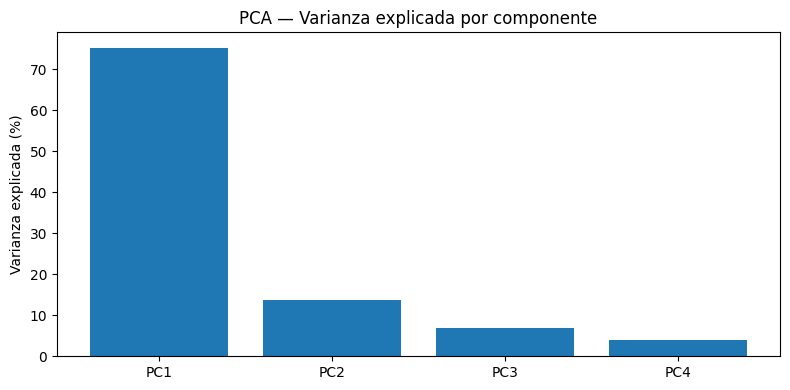

Varianza explicada (correlación):
  PC1: 43.0%
  PC2: 24.2%
  PC3: 16.5%
  PC4: 16.3%

Primer eigenvector (PC1):
  AAPL: -0.5673
  TSLA: -0.5663
  AMZN: -0.2569
  GLD: -0.5399


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Mismos datos de ayer
tickers = ["AAPL", "TSLA", "AMZN", "GLD"]
data = yf.download(tickers, start="2024-01-01", end="2024-12-31")["Close"]
returns = np.log(data / data.shift(1)).dropna()

# Matriz de covarianza
cov_matrix = returns.cov().values

# Eigenvalores y eigenvectores
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Ordenar de mayor a menor
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Varianza explicada por cada componente
varianza_explicada = eigenvalues / eigenvalues.sum() * 100

print("Eigenvalores:", eigenvalues.round(6))
print("\nVarianza explicada por cada componente:")
for i, v in enumerate(varianza_explicada):
    print(f"  PC{i+1}: {v:.1f}%")

print("\nPrimer eigenvector (PC1):")
for ticker, peso in zip(tickers, eigenvectors[:, 0]):
    print(f"  {ticker}: {peso:.4f}")

# Gráfica
plt.figure(figsize=(8, 4))
plt.bar([f"PC{i+1}" for i in range(len(eigenvalues))], varianza_explicada)
plt.ylabel("Varianza explicada (%)")
plt.title("PCA — Varianza explicada por componente")
plt.tight_layout()
plt.show()

# PCA correcto — sobre matriz de correlación
corr_matrix = returns.corr().values

eigenvalues_c, eigenvectors_c = np.linalg.eig(corr_matrix)

idx = eigenvalues_c.argsort()[::-1]
eigenvalues_c = eigenvalues_c[idx]
eigenvectors_c = eigenvectors_c[:, idx]

varianza_explicada_c = eigenvalues_c / eigenvalues_c.sum() * 100

print("Varianza explicada (correlación):")
for i, v in enumerate(varianza_explicada_c):
    print(f"  PC{i+1}: {v:.1f}%")

print("\nPrimer eigenvector (PC1):")
for ticker, peso in zip(tickers, eigenvectors_c[:, 0]):
    print(f"  {ticker}: {peso:.4f}")

## Mini proyecto del dia

Proyectar retornos sobre PCA

Correlación PC1 con cada activo:
  AAPL: -0.744
  TSLA: -0.708
  AMZN: -0.743
  GLD: -0.337

Correlación PC2 con cada activo:
  AAPL: -0.097
  TSLA: -0.326
  AMZN: -0.011
  GLD: 0.923


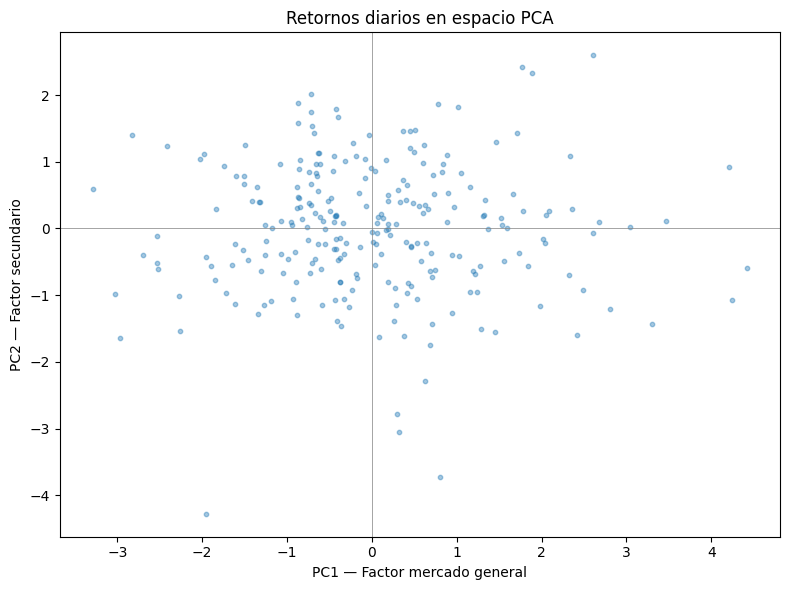

In [38]:
# Proyectar retornos sobre componentes principales
# (transformar datos al espacio PCA)
from sklearn.preprocessing import StandardScaler

# Estandarizar retornos
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

# Proyectar sobre los 2 primeros PCs
pc_scores = returns_scaled @ eigenvectors_c[:, :2]
pc_scores = pd.DataFrame(pc_scores, 
                          columns=["PC1_mercado", "PC2_tech_vs_oro"],
                          index=returns.index)

# Correlación de cada PC con los activos originales
print("Correlación PC1 con cada activo:")
for ticker in tickers:
    corr = pc_scores["PC1_mercado"].corr(returns[ticker])
    print(f"  {ticker}: {corr:.3f}")

print("\nCorrelación PC2 con cada activo:")
for ticker in tickers:
    corr = pc_scores["PC2_tech_vs_oro"].corr(returns[ticker])
    print(f"  {ticker}: {corr:.3f}")

# Gráfica de los retornos proyectados en el espacio PC1-PC2
plt.figure(figsize=(8,6))
plt.scatter(pc_scores["PC1_mercado"], 
            pc_scores["PC2_tech_vs_oro"], 
            alpha=0.4, s=10)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel("PC1 — Factor mercado general")
plt.ylabel("PC2 — Factor secundario")
plt.title("Retornos diarios en espacio PCA")
plt.tight_layout()
plt.show()

Muy buena interpretación del PC2 — la lógica de "burbuja tech → rotación a oro" es exactamente el tipo de razonamiento que un quant researcher usa para darle nombre a un factor.
Sobre la gráfica, la dispersión mayor en PC1 que en PC2 es consistente con que PC1 explica más varianza (43% vs 24%). Los puntos cerca del origen significan que la mayoría de los días los movimientos son pequeños — los días extremos (crisis, rally fuerte) son los puntos alejados del centro.

PC1 (43% varianza) = Mercado general
   → AAPL, AMZN, TSLA se mueven juntas
   → GLD apenas participa

PC2 (24% varianza) = Rotación de riesgo  
   → GLD sube cuando TSLA baja
   → AAPL y AMZN casi no participan

Calculo del PC3

Correlación PC1 con cada activo:
  AAPL: -0.744
  TSLA: -0.708
  AMZN: -0.743
  GLD: -0.337

Correlación PC2 con cada activo:
  AAPL: -0.097
  TSLA: -0.326
  AMZN: -0.011
  GLD: 0.923

Correlación PC3 con cada activo:
  AAPL: 0.247
  TSLA: 0.368
  AMZN: -0.665
  GLD: 0.148


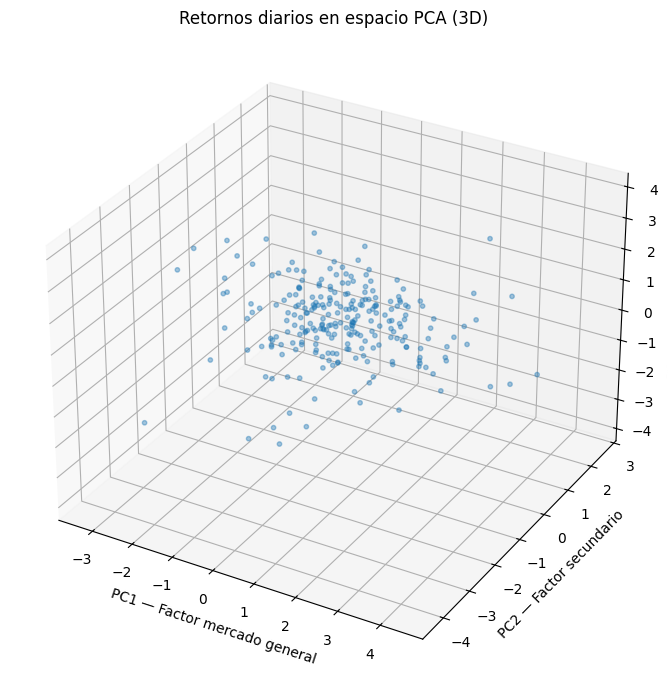

In [40]:
from sklearn.preprocessing import StandardScaler

# Estandarizar retornos
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

# Proyectar sobre los 3 primeros PCs
pc_scores = returns_scaled @ eigenvectors_c[:, :3]
pc_scores = pd.DataFrame(pc_scores, 
                          columns=["PC1_mercado", "PC2_tech_vs_oro", "PC3_factor_extra"],
                          index=returns.index)

# Correlación de cada PC con los activos originales
print("Correlación PC1 con cada activo:")
for ticker in tickers:
    corr = pc_scores["PC1_mercado"].corr(returns[ticker])
    print(f"  {ticker}: {corr:.3f}")

print("\nCorrelación PC2 con cada activo:")
for ticker in tickers:
    corr = pc_scores["PC2_tech_vs_oro"].corr(returns[ticker])
    print(f"  {ticker}: {corr:.3f}")

print("\nCorrelación PC3 con cada activo:")
for ticker in tickers:
    corr = pc_scores["PC3_factor_extra"].corr(returns[ticker])
    print(f"  {ticker}: {corr:.3f}")

# Gráfica de los retornos proyectados en el espacio PC1-PC2-PC3
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pc_scores["PC1_mercado"], 
           pc_scores["PC2_tech_vs_oro"], 
           pc_scores["PC3_factor_extra"], 
           alpha=0.4, s=10)

ax.set_xlabel("PC1 — Factor mercado general")
ax.set_ylabel("PC2 — Factor secundario")
ax.set_zlabel("PC3 — Factor terciario")
ax.set_title("Retornos diarios en espacio PCA (3D)")
plt.tight_layout()
plt.show()


Ley de probabilidad total



In [46]:
P_sube = 0.5
P_baja = 0.5
P_VIX_sube_mercado_baja = 0.8
P_VIX_baja_mercado_sube = 0.2

## Calculo de la ley de probabilidad total para saber que tanto sube VIX sin importar lo que el mercado haga

P_VIX = 0.8*0.5 + 0.2*0.5
print(f"Probabilidad que el VIX suba es de {round(P_VIX, 2)*100}%")

#Probabilidad que el mercado baje dado que el VIX sube

P_mercado_baja_VIX_sube = 0.8 * 0.5 / P_VIX
print(f"La probabilidad que el mercado baje dado que el VIX sube es de {round(P_mercado_baja_VIX_sube, 2) *100}%")

Probabilidad que el VIX suba es de 50.0%
La probabilidad que el mercado baje dado que el VIX sube es de 80.0%


3. Variables aleatorias y distribuciones


[*********************100%***********************]  4 of 4 completed


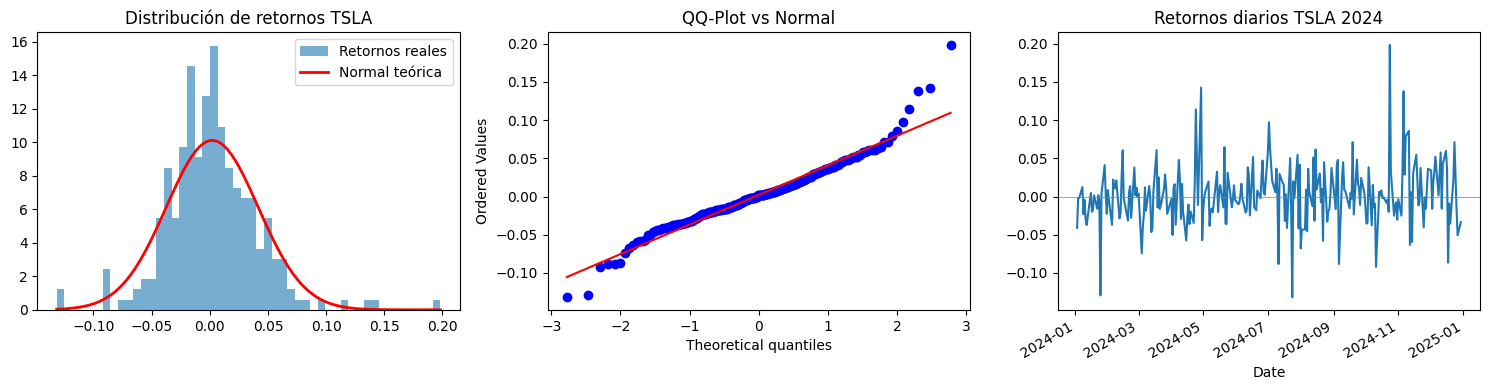

Media:     0.002076
Std:       0.039465
Skewness:  0.5693
Kurtosis:  3.5617

Shapiro-Wilk p-value: 0.009029
¿Normal? No — rechazamos normalidad


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf

# Datos
tickers = ["AAPL", "TSLA", "AMZN", "GLD"]
data = yf.download(tickers, start="2024-01-01", end="2024-12-31")["Close"]
returns = np.log(data / data.shift(1)).dropna()

# Enfocamos en TSLA — el más volátil
r = returns["TSLA"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histograma vs Normal
ax = axes[0]
ax.hist(r, bins=50, density=True, alpha=0.6, label="Retornos reales")
x = np.linspace(r.min(), r.max(), 100)
ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 
        'r-', linewidth=2, label="Normal teórica")
ax.set_title("Distribución de retornos TSLA")
ax.legend()

# 2. QQ-Plot
ax = axes[1]
stats.probplot(r, dist="norm", plot=ax)
ax.set_title("QQ-Plot vs Normal")

# 3. Retornos en el tiempo
ax = axes[2]
r.plot(ax=ax)
ax.set_title("Retornos diarios TSLA 2024")
ax.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

# Estadísticas
print(f"Media:     {r.mean():.6f}")
print(f"Std:       {r.std():.6f}")
print(f"Skewness:  {r.skew():.4f}")
print(f"Kurtosis:  {r.kurtosis():.4f}")

# Test de normalidad — tu Shapiro-Wilk
stat, p = stats.shapiro(r.sample(50, random_state=42))
print(f"\nShapiro-Wilk p-value: {p:.6f}")
print(f"¿Normal? {'Sí' if p > 0.05 else 'No — rechazamos normalidad'}")

Prueba t-student


Grados de libertad (ν): 4.23
Media:                  0.000574
Escala:                 0.028919


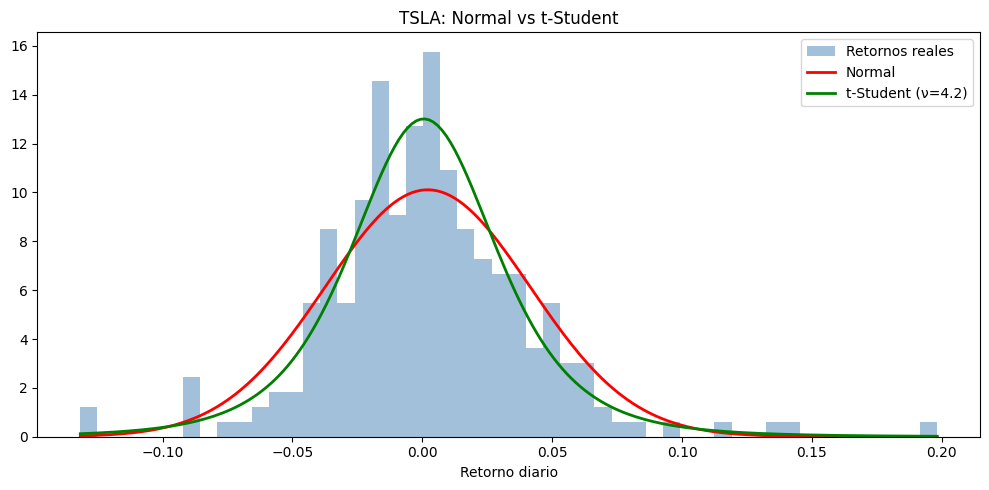


P(retorno < -5% en un día):
  Normal:    9.349%
  t-Student: 7.565%
  Ratio:     0.8x más probable según t-Student


In [49]:
# Ajustar distribución t-Student a retornos de TSLA
from scipy.stats import t

# Estimar parámetros (nu, media, escala)
nu, mu, sigma = t.fit(r)

print(f"Grados de libertad (ν): {nu:.2f}")
print(f"Media:                  {mu:.6f}")
print(f"Escala:                 {sigma:.6f}")

# Comparar Normal vs t-Student visualmente
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma real
ax.hist(r, bins=50, density=True, alpha=0.5, 
        label="Retornos reales", color="steelblue")

x = np.linspace(r.min(), r.max(), 200)

# Normal
ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 
        'r-', linewidth=2, label="Normal")

# t-Student ajustada
ax.plot(x, t.pdf(x, nu, mu, sigma), 
        'g-', linewidth=2, label=f"t-Student (ν={nu:.1f})")

ax.set_title("TSLA: Normal vs t-Student")
ax.set_xlabel("Retorno diario")
ax.legend()
plt.tight_layout()
plt.show()

# Comparar probabilidad de evento extremo
umbral = -0.05  # caída de 5% en un día
p_normal = stats.norm.cdf(umbral, r.mean(), r.std())
p_t = t.cdf(umbral, nu, mu, sigma)

print(f"\nP(retorno < -5% en un día):")
print(f"  Normal:    {p_normal*100:.3f}%")
print(f"  t-Student: {p_t*100:.3f}%")
print(f"  Ratio:     {p_t/p_normal:.1f}x más probable según t-Student")

In [50]:
umbral = -0.05
std_real = r.std()
mean_real = r.mean()

p_normal = stats.norm.cdf(umbral, mean_real, std_real)

escala_ajustada = std_real * np.sqrt((nu-2)/nu)
p_t_ajustada = t.cdf(umbral, nu, mean_real, escala_ajustada)

print(f"Comparación con misma volatilidad:")
print(f"  Normal:              {p_normal*100:.3f}%")
print(f"  t-Student (ν={nu:.1f}): {p_t_ajustada*100:.3f}%")
print(f"  Ratio: {p_t_ajustada/p_normal:.2f}x")

Comparación con misma volatilidad:
  Normal:              9.349%
  t-Student (ν=4.2): 6.971%
  Ratio: 0.75x


In [51]:
# Diagnóstico
print(f"nu:             {nu:.4f}")
print(f"mean_real:      {mean_real:.6f}")
print(f"std_real:       {std_real:.6f}")
print(f"escala_ajustada:{escala_ajustada:.6f}")
print(f"umbral:         {umbral}")

# Cuántas desviaciones estándar es -5%?
print(f"\n-5% está a {(umbral - mean_real)/std_real:.2f} desviaciones estándar de la media")

# Verificación manual
from scipy.stats import norm, t
z = (umbral - mean_real) / std_real
print(f"P(Z < {z:.2f}) normal: {norm.cdf(z)*100:.3f}%")

nu:             4.2309
mean_real:      0.002076
std_real:       0.039465
escala_ajustada:0.028657
umbral:         -0.05

-5% está a -1.32 desviaciones estándar de la media
P(Z < -1.32) normal: 9.349%


In [52]:

for umbral_test in [-0.05, -0.10, -0.15, -0.20]:
    sigmas = (umbral_test - mean_real) / std_real
    p_n = stats.norm.cdf(umbral_test, mean_real, std_real)
    p_t = t.cdf(umbral_test, nu, mean_real, escala_ajustada)
    print(f"Umbral {umbral_test*100:.0f}% ({sigmas:.1f}σ): "
          f"Normal={p_n*100:.4f}%  "
          f"t-Student={p_t*100:.4f}%  "
          f"Ratio={p_t/p_n:.2f}x")

Umbral -5% (-1.3σ): Normal=9.3492%  t-Student=6.9711%  Ratio=0.75x
Umbral -10% (-2.6σ): Normal=0.4848%  t-Student=1.0717%  Ratio=2.21x
Umbral -15% (-3.9σ): Normal=0.0058%  t-Student=0.2585%  Ratio=44.40x
Umbral -20% (-5.1σ): Normal=0.0000%  t-Student=0.0862%  Ratio=5653.00x


-5%  (-1.3σ): Normal=9.35%      t-Student=6.97%    → Normal > t
-10% (-2.6σ): Normal=0.48%      t-Student=1.07%    → t 2x mayor
-15% (-3.9σ): Normal=0.006%     t-Student=0.26%    → t 44x mayor
-20% (-5.1σ): Normal=0.000003%  t-Student=0.086%   → t 5,653x mayor
El ratio explota exponencialmente en las colas. A -20% en un día:

La normal dice que es prácticamente imposible (0.000003%)
La t-Student dice que ocurre con probabilidad 0.086% — aproximadamente 1 vez cada 3 años

Y si miras el historial de TSLA, caídas de 15-20% en un día sí han ocurrido. La normal las clasificaría como eventos de "una vez en un millón de años". La t-Student las ve como eventos raros pero reales.
Esta es exactamente la razón por la que los modelos de riesgo basados en normalidad fallan en crisis. En 2008, los modelos de VaR de los bancos usaban distribuciones normales. Los eventos que ocurrieron eran "imposibles" según esos modelos — pero ocurrieron. Long-Term Capital Management (LTCM), el hedge fund más famoso de la historia, quebró en 1998 por exactamente esto: modelos que subestimaban la probabilidad de eventos extremos.